In [2]:
import pandas as pd

In [6]:
df = pd.read_csv("Online Retail.csv", encoding="latin1")
print(df.head())

ParserError: Error tokenizing data. C error: Expected 2 fields in line 111, saw 3


In [7]:
df = pd.read_csv("Online Retail.csv", encoding="latin1", sep=";")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate UnitPrice  CustomerID         Country  
0  1.12.2010 8:26      2,55     17850.0  United Kingdom  
1  1.12.2010 8:26      3,39     17850.0  United Kingdom  
2  1.12.2010 8:26      2,75     17850.0  United Kingdom  
3  1.12.2010 8:26      3,39     17850.0  United Kingdom  
4  1.12.2010 8:26      3,39     17850.0  United Kingdom  


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  object 
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
#odstránime riadky, kde sú nulové hodnoty CustomerID
df_clean = df.dropna(subset=["CustomerID"])
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  object 
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 27.9+ MB
None


In [11]:
#ideme preskúmavať jednotlivé stĺpce, aké hodnoty obsahujú
df_clean["InvoiceNo"].head(10)

0    536365
1    536365
2    536365
3    536365
4    536365
5    536365
6    536365
7    536366
8    536366
9    536367
Name: InvoiceNo, dtype: object

In [12]:
#pozrieme sa na vzorku unikátnych hodnôt
df_clean["InvoiceNo"].unique()[:20]

array(['536365', '536366', '536367', '536368', '536369', '536370',
       '536371', '536372', '536373', '536374', '536375', '536376',
       '536377', '536378', '536380', '536381', 'C536379', '536382',
       'C536383', '536384'], dtype=object)

In [13]:
#zistíme, či sú v tom stĺpci hodnoty, ktoré nie sú čísla
df_clean[~df_clean["InvoiceNo"].str.isnumeric()]["InvoiceNo"].unique()

array(['C536379', 'C536383', 'C536391', ..., 'C581499', 'C581568',
       'C581569'], shape=(3654,), dtype=object)

In [14]:
df_clean[df_clean["InvoiceNo"].str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,1.12.2010 9:41,"27,5",14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,1.12.2010 9:49,"4,65",15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.12.2010 10:24,"1,65",17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,1.12.2010 10:24,"0,29",17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,1.12.2010 10:24,"0,29",17548.0,United Kingdom


In [15]:
#vidíme, že v riadkoch, kde sa hodnota InvoiceNo začína písmenom C, sú Quantity hodnoty záporné. To znamená, že ide o storno/refund objednávky
#odstránime storno objednávky
df_final = df_clean[~df_clean["InvoiceNo"].str.startswith("C")]
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397924 non-null  object 
 1   StockCode    397924 non-null  object 
 2   Description  397924 non-null  object 
 3   Quantity     397924 non-null  int64  
 4   InvoiceDate  397924 non-null  object 
 5   UnitPrice    397924 non-null  object 
 6   CustomerID   397924 non-null  float64
 7   Country      397924 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 27.3+ MB
None


In [16]:
#teraz ideme na prvý report
#chcem vedieť celkové tržby podľa krajín
df_final["Revenue"] = df_final["Quantity"] * df_final["UnitPrice"]
df_final.head()

C:\Users\matus\AppData\Local\Temp\ipykernel_10660\4016787371.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["Revenue"] = df_final["Quantity"] * df_final["UnitPrice"]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,1.12.2010 8:26,"2,55",17850.0,United Kingdom,"2,552,552,552,552,552,55"
1,536365,71053,WHITE METAL LANTERN,6,1.12.2010 8:26,"3,39",17850.0,United Kingdom,"3,393,393,393,393,393,39"
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,1.12.2010 8:26,"2,75",17850.0,United Kingdom,"2,752,752,752,752,752,752,752,75"
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,1.12.2010 8:26,"3,39",17850.0,United Kingdom,"3,393,393,393,393,393,39"
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,1.12.2010 8:26,"3,39",17850.0,United Kingdom,"3,393,393,393,393,393,39"


In [17]:
#premeníme hodnoty UnitPrice zo stringu na float
df_final["UnitPrice"] = df_final["UnitPrice"].str.replace(",", ".", regex=False)
df_final["UnitPrice"] = df_final["UnitPrice"].astype(float)

df_final[["UnitPrice"]].head()

C:\Users\matus\AppData\Local\Temp\ipykernel_10660\237144450.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["UnitPrice"] = df_final["UnitPrice"].str.replace(",", ".", regex=False)
C:\Users\matus\AppData\Local\Temp\ipykernel_10660\237144450.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["UnitPrice"] = df_final["UnitPrice"].astype(float)


,UnitPrice
0,2.55
1,3.39
2,2.75
3,3.39
4,3.39


In [18]:
#zistíme typy hodnôt dát, aby sme sa vyhli podobným chybám, že v reportoch ideme násobiť stringy
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice       object
CustomerID     float64
Country         object
dtype: object

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,1.12.2010 8:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,1.12.2010 8:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,1.12.2010 8:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,1.12.2010 8:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,1.12.2010 8:26,"3,39",17850.0,United Kingdom


In [20]:
df_final["Revenue"] = df_final["Quantity"] * df_final["UnitPrice"]
df_final[["Quantity", "UnitPrice", "Revenue"]].head()

C:\Users\matus\AppData\Local\Temp\ipykernel_10660\1483018643.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["Revenue"] = df_final["Quantity"] * df_final["UnitPrice"]


,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [21]:
#chcem vedieť tržby podľa krajín
df_country = df_final.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

df_country.head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

In [22]:
#uloženie do Excelu pre klienta
df_country.to_excel("report_trzby_podla_krajin.xlsx")

In [24]:
#Ktorí zákazníci mi prinášajú najviac peňazí?
df_customer = df_final.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)

df_customer.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [25]:
#opravíme typ hodnôt Customer ID, lebo teraz je to float. Chceme int
df_final["CustomerID"] = df_final["CustomerID"].astype(int)

C:\Users\matus\AppData\Local\Temp\ipykernel_10660\2464367145.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["CustomerID"] = df_final["CustomerID"].astype(int)


In [26]:
df_customer = df_final.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
df_customer.head(10)

CustomerID
14646    280206.02
18102    259657.30
17450    194550.79
16446    168472.50
14911    143825.06
12415    124914.53
14156    117379.63
17511     91062.38
16029     81024.84
12346     77183.60
Name: Revenue, dtype: float64

In [27]:
#ktoré produkty mi zarábajú najviac?
df_product = df_final.groupby("Description")["Revenue"].sum().sort_values(ascending=False)

df_product.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

In [28]:
#chceme si overiť ešte tržby podľa Description a StockCode
df_final.groupby(["StockCode", "Description"])["Revenue"].sum().sort_values(ascending=False).head(10)

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
22423      REGENCY CAKESTAND 3 TIER              142592.95
85123A     WHITE HANGING HEART T-LIGHT HOLDER    100448.15
85099B     JUMBO BAG RED RETROSPOT                85220.78
23166      MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POST       POSTAGE                                77803.96
47566      PARTY BUNTING                          68844.33
84879      ASSORTED COLOUR BIRD ORNAMENT          56580.34
M          Manual                                 53779.93
23084      RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

In [30]:
df_final[df_final["StockCode"].isin(["POST", "M"])].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
45,536370,POST,POSTAGE,3,1.12.2010 8:45,18.00,12583,France,54.00
386,536403,POST,POSTAGE,1,1.12.2010 11:27,15.00,12791,Netherlands,15.00
1123,536527,POST,POSTAGE,1,1.12.2010 13:04,18.00,12662,Germany,18.00
2239,536569,M,Manual,1,1.12.2010 15:35,1.25,16274,United Kingdom,1.25
2250,536569,M,Manual,1,1.12.2010 15:35,18.95,16274,United Kingdom,18.95


In [31]:
#chcem zistiť, v koľkých riadkoch sú hodnoty POST a M
df_final["StockCode"].isin(["POST", "M"]).sum()

np.int64(1389)

In [32]:
#odstránime neprodukty
df_products = df_final[~df_final["StockCode"].isin(["POST", "M"])]
print(df_products.info())

<class 'pandas.core.frame.DataFrame'>
Index: 396535 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    396535 non-null  object 
 1   StockCode    396535 non-null  object 
 2   Description  396535 non-null  object 
 3   Quantity     396535 non-null  int64  
 4   InvoiceDate  396535 non-null  object 
 5   UnitPrice    396535 non-null  float64
 6   CustomerID   396535 non-null  int64  
 7   Country      396535 non-null  object 
 8   Revenue      396535 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 30.3+ MB
None


In [33]:
# chcem zistiť, či stĺpec obsahuje aj iné čudné hodnoty ako M a POST (profiling stĺpcov)
#najprv unikátne hodnoty/vzory
df["StockCode"].unique()[:20]

array(['85123A', '71053', '84406B', '84029G', '84029E', '22752', '21730',
       '22633', '22632', '84879', '22745', '22748', '22749', '22310',
       '84969', '22623', '22622', '21754', '21755', '21777'], dtype=object)

In [34]:
#frekvencia
df["StockCode"].value_counts().head(10)

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
Name: count, dtype: int64

In [35]:
#typ hodnoty (pattern)
df["StockCode"].str.isnumeric().value_counts()

StockCode
True     487036
False     54873
Name: count, dtype: int64

In [36]:
#identifikujeme "divné" StockCode
df_products[~df_products["StockCode"].str.isnumeric()]["StockCode"].value_counts().head(20)

StockCode
85123A    2035
85099B    1618
82494L     820
85099F     664
85099C     659
84997D     429
84970S     415
47591D     401
15056N     382
84596B     379
47590B     363
47590A     356
85049E     347
84970L     338
84997B     330
84029E     328
84029G     326
47566B     317
84997C     309
85014B     306
Name: count, dtype: int64

In [37]:
#business profiling-čo je naozaj NEPORUDKT?
df_products["Description"].value_counts().head(20)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1724
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1397
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
PACK OF 72 RETROSPOT CAKE CASES       1068
PAPER CHAIN KIT 50'S CHRISTMAS        1019
SPOTTY BUNTING                        1017
LUNCH BAG SPACEBOY DESIGN             1008
LUNCH BAG CARS BLUE                    989
HEART OF WICKER SMALL                  985
NATURAL SLATE HEART CHALKBOARD         980
LUNCH BAG PINK POLKADOT                957
REX CASH+CARRY JUMBO SHOPPER           952
LUNCH BAG SUKI DESIGN                  933
ALARM CLOCK BAKELIKE RED               899
LUNCH BAG APPLE DESIGN                 895
Name: count, dtype: int64

In [38]:
#chceme zistiť, ako sa vyvíjali tržby v čase. Najprv musíme zmeniť dátum
df_products["InvoiceDate"] = pd.to_datetime(df_products["InvoiceDate"])

ValueError: time data "13.12.2010 9:02" doesn't match format "%m.%d.%Y %H:%M", at position 812. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [39]:
#musíme zmeniť európsky formát dátumu
df_products["InvoiceDate"] = pd.to_datetime(df_products["InvoiceDate"], dayfirst=True)

C:\Users\matus\AppData\Local\Temp\ipykernel_10660\3897575169.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_products["InvoiceDate"] = pd.to_datetime(df_products["InvoiceDate"], dayfirst=True)


In [40]:
df_products["InvoiceDate"]

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 396535, dtype: datetime64[ns]

In [41]:
#vytvoríme mesiac
df_products["Month"] = df_products["InvoiceDate"].dt.to_period("M")

C:\Users\matus\AppData\Local\Temp\ipykernel_10660\2524766337.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_products["Month"] = df_products["InvoiceDate"].dt.to_period("M")


In [42]:
#mesačné tržby
df_month = df_products.groupby("Month")["Revenue"].sum()

df_month

Month
2010-12     568055.720
2011-01     564241.640
2011-02     443546.020
2011-03     585262.850
2011-04     455681.911
2011-05     660932.900
2011-06     654932.560
2011-07     593231.901
2011-08     637168.410
2011-09     943512.642
2011-10    1009781.660
2011-11    1148481.110
2011-12     514994.690
Freq: M, Name: Revenue, dtype: float64

<Axes: xlabel='Month'>

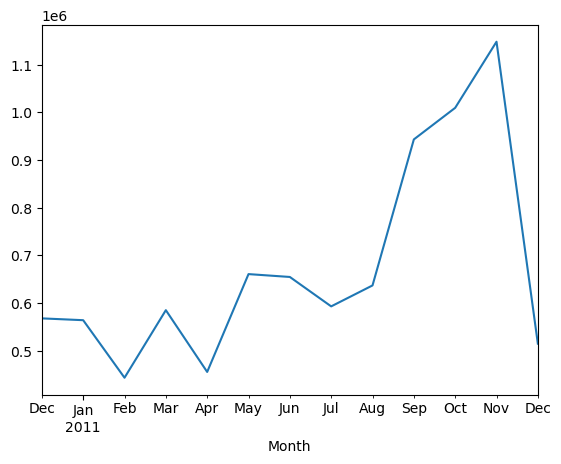

In [43]:
#spravíme graf
df_month.plot()

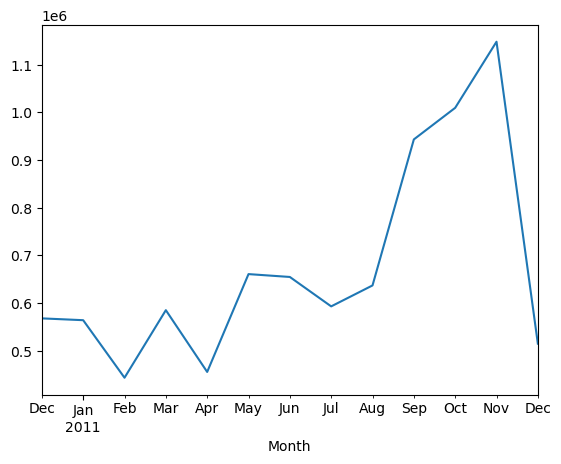

In [44]:
#uloženie grafu
import matplotlib.pyplot as plt

df_month.plot()
plt.savefig("mesacne_trzby.png")

In [45]:
#------------------------------------------------------------------------------------------------------------------
#DATA PROFILING
# základný pohľad na zákaznícke dáta
print("Počet riadkov:", len(df_products))
print("Počet unikátnych zákazníkov:", df_products['CustomerID'].nunique())
print("Chýbajúce CustomerID:", df_products['CustomerID'].isna().sum())

print("\nDátum od:", df_products['InvoiceDate'].min())
print("Dátum do:", df_products['InvoiceDate'].max())

Počet riadkov: 396535
Počet unikátnych zákazníkov: 4336
Chýbajúce CustomerID: 0

Dátum od: 2010-12-01 08:26:00
Dátum do: 2011-12-09 12:50:00


In [46]:
#vytvoríme customer-level tabuľku
customer_profile = df_products.groupby('CustomerID').agg(
    total_revenue=('Revenue', 'sum'),
    num_orders=('InvoiceNo', 'nunique'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max')
).reset_index()

customer_profile.head()

,CustomerID,total_revenue,num_orders,first_purchase,last_purchase
0,12346,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347,4310.00,7,2010-12-07 14:57:00,2011-12-07 15:52:00
2,12348,1437.24,4,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12349,1457.55,1,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350,294.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00


In [47]:
customer_profile.describe()

,CustomerID,total_revenue,num_orders,first_purchase,last_purchase
count,4336.000000,4336.000000,4336.000000,4336,4336
mean,15298.901292,2024.867162,4.247924,2011-04-30 17:22:14.944649216,2011-09-08 07:56:00.221402112
min,12346.000000,0.000000,1.000000,2010-12-01 08:26:00,2010-12-01 09:53:00
25%,13811.750000,305.717500,1.000000,2011-01-17 11:11:15,2011-07-20 11:03:00
50%,15297.500000,668.075000,2.000000,2011-04-05 09:52:30,2011-10-20 09:48:30
75%,16778.250000,1631.327500,5.000000,2011-08-19 10:52:15,2011-11-22 11:13:15
max,18287.000000,279138.020000,206.000000,2011-12-09 12:16:00,2011-12-09 12:50:00
std,1721.894850,8939.837297,7.647368,NaN,NaN


In [48]:
#koľko zákazníkov má len jednu objednávku
(customer_profile['num_orders'] == 1).mean()

np.float64(0.34732472324723246)

In [49]:
#potrebujeme referenčný dátum (tzv.snapshot date)
snapshot_date = df_products['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [50]:
#vypočítame Recency (stále bez RFM skóre)
customer_profile['recency_days'] = (
    snapshot_date - customer_profile['last_purchase']
).dt.days

customer_profile[['CustomerID', 'last_purchase', 'recency_days']].head()

,CustomerID,last_purchase,recency_days
0,12346,2011-01-18 10:01:00,326
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310


In [51]:
#ako vyzerá rozdelenie Recency
customer_profile['recency_days'].describe()

count    4336.000000
mean       92.690498
std       100.202189
min         1.000000
25%        18.000000
50%        51.000000
75%       143.000000
max       374.000000
Name: recency_days, dtype: float64

In [52]:
#preskúmame Frequency (2.časť RFM)
customer_profile['num_orders'].describe()

count    4336.000000
mean        4.247924
std         7.647368
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       206.000000
Name: num_orders, dtype: float64

In [53]:
#preskúmame Monetary (total_revenue) (3.časť RFM)
customer_profile['total_revenue'].describe()

count      4336.000000
mean       2024.867162
std        8939.837297
min           0.000000
25%         305.717500
50%         668.075000
75%        1631.327500
max      279138.020000
Name: total_revenue, dtype: float64

In [54]:
#najprv si pozrieme distribúciu (percentily), ktoré použijeme na rozdelenie do skupín.
customer_profile[['recency_days', 'num_orders', 'total_revenue']].quantile([0.2, 0.4, 0.6, 0.8])

,recency_days,num_orders,total_revenue
0.2,14.0,1.0,248.10
0.4,33.0,2.0,484.82
0.6,72.0,3.0,925.85
0.8,179.0,5.0,2043.23


In [55]:
#vytvorenie RFM skóre
# Recency score (nižšie = lepšie → opačné poradie)
def r_score(x):
    if x <= 14:
        return 5
    elif x <= 33:
        return 4
    elif x <= 72:
        return 3
    elif x <= 179:
        return 2
    else:
        return 1

# Frequency score (vyššie = lepšie)
def f_score(x):
    if x <= 1:
        return 1
    elif x <= 2:
        return 2
    elif x <= 3:
        return 3
    elif x <= 5:
        return 4
    else:
        return 5

# Monetary score (vyššie = lepšie)
def m_score(x):
    if x <= 248:
        return 1
    elif x <= 484:
        return 2
    elif x <= 925:
        return 3
    elif x <= 2043:
        return 4
    else:
        return 5

In [56]:
#aplikácia na dáta
customer_profile['R'] = customer_profile['recency_days'].apply(r_score)
customer_profile['F'] = customer_profile['num_orders'].apply(f_score)
customer_profile['M'] = customer_profile['total_revenue'].apply(m_score)

customer_profile[['CustomerID', 'R', 'F', 'M']].head()

,CustomerID,R,F,M
0,12346,1,1,5
1,12347,5,5,5
2,12348,2,4,4
3,12349,4,1,4
4,12350,1,1,2


In [57]:
#skontrolujeme, či skórovanie vzniklo správne
customer_profile[['R', 'F', 'M']].describe()

,R,F,M
count,4336.000000,4336.000000,4336.000000
mean,3.018681,2.658441,3.002076
std,1.418894,1.551808,1.414620
min,1.000000,1.000000,1.000000
25%,2.000000,1.000000,2.000000
50%,3.000000,2.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000


In [58]:
#spojíme R,F, M do jedného kódu
customer_profile['RFM_score'] = (
    customer_profile['R'].astype(str) +
    customer_profile['F'].astype(str) +
    customer_profile['M'].astype(str)
)

customer_profile[['CustomerID', 'R', 'F', 'M', 'RFM_score']].head()

,CustomerID,R,F,M,RFM_score
0,12346,1,1,5,115
1,12347,5,5,5,555
2,12348,2,4,4,244
3,12349,4,1,4,414
4,12350,1,1,2,112


In [59]:
#pozrieme aké kombinácie RFM sú najčastejšie
customer_profile['RFM_score'].value_counts().head(10)

RFM_score
555    351
111    328
112    211
455    177
211    144
311    128
212    106
312    106
411     91
223     91
Name: count, dtype: int64

In [60]:
#prvá segmentácia
def segment_customer(row):
    if row['R'] == 5 and row['F'] >= 4:
        return 'VIP'

    elif row['R'] >= 4 and row['F'] >= 3:
        return 'Loyal'

    elif row['R'] >= 3:
        return 'Active'

    elif row['R'] == 2:
        return 'At Risk'

    else:
        return 'Churn'


customer_profile['segment'] = customer_profile.apply(segment_customer, axis=1)

customer_profile[['CustomerID', 'RFM_score', 'segment']].head()

,CustomerID,RFM_score,segment
0,12346,115,Churn
1,12347,555,VIP
2,12348,244,At Risk
3,12349,414,Active
4,12350,112,Churn


In [61]:
#poďme spočítať segmenty
customer_profile['segment'].value_counts()

segment
Active     1391
Churn       867
At Risk     839
Loyal       626
VIP         613
Name: count, dtype: int64

In [62]:
#teraz sa zameriame na TOP zákazníkov (Pareto analýza)
#zoradenie zákazníkov podľa revenue
customer_profile_sorted = customer_profile.sort_values(by='total_revenue', ascending=False)

customer_profile_sorted[['CustomerID', 'total_revenue']].head()

,CustomerID,total_revenue
1690,14646,279138.02
4199,18102,259657.30
3727,17450,194550.79
3008,16446,168472.50
1880,14911,140450.72


In [63]:
#kumulatívne revenue
# celkový revenue
total_revenue_sum = customer_profile_sorted['total_revenue'].sum()

# kumulatívny revenue
customer_profile_sorted['cum_revenue'] = customer_profile_sorted['total_revenue'].cumsum()

# kumulatívne percento
customer_profile_sorted['cum_revenue_pct'] = (
    customer_profile_sorted['cum_revenue'] / total_revenue_sum
)

customer_profile_sorted[['CustomerID', 'total_revenue', 'cum_revenue_pct']].head(10)

,CustomerID,total_revenue,cum_revenue_pct
1690,14646,279138.02,0.031793
4199,18102,259657.30,0.061367
3727,17450,194550.79,0.083526
3008,16446,168472.50,0.102715
1880,14911,140450.72,0.118712
55,12415,124564.53,0.132899
1334,14156,117379.63,0.146269
3770,17511,91062.38,0.156640
0,12346,77183.60,0.165432
2702,16029,72882.09,0.173733


In [64]:
# nájdime hranicu 80 %-koľko zákazníkov spraví 80 % revenue
top_80 = customer_profile_sorted[
    customer_profile_sorted['cum_revenue_pct'] <= 0.8
]

len(top_80)

1134

In [65]:
#ešte percento zákazníkov
len(top_80) / len(customer_profile_sorted)

0.2615313653136531

In [66]:
#prepojenie s RFM-Ktoré RFM segmenty tvoria tých TOP 26 %?
#zistíme, aké segmenty sú v TOP 80 % revenue
top_80['segment'].value_counts()

segment
VIP        460
Loyal      297
Active     218
At Risk    120
Churn       39
Name: count, dtype: int64

In [67]:
#vizualizácia Pareto analýzy
#pripravíme % zákazníkov
customer_profile_sorted = customer_profile_sorted.reset_index(drop=True)

customer_profile_sorted['customer_pct'] = (
    (customer_profile_sorted.index + 1) / len(customer_profile_sorted)
)

customer_profile_sorted[['customer_pct', 'cum_revenue_pct']].head()

,customer_pct,cum_revenue_pct
0,0.000231,0.031793
1,0.000461,0.061367
2,0.000692,0.083526
3,0.000923,0.102715
4,0.001153,0.118712


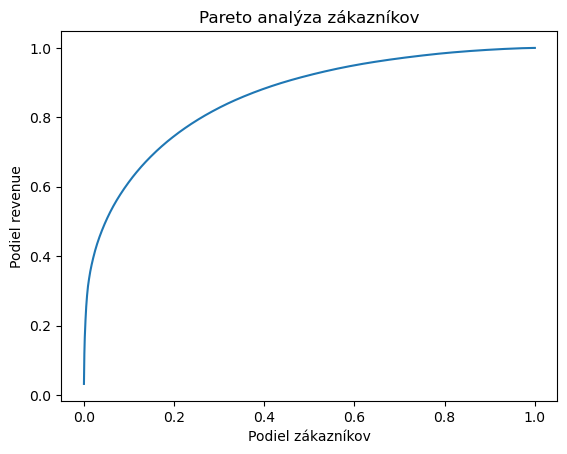

In [68]:
#Pareto graf
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    customer_profile_sorted['customer_pct'],
    customer_profile_sorted['cum_revenue_pct']
)

plt.xlabel('Podiel zákazníkov')
plt.ylabel('Podiel revenue')
plt.title('Pareto analýza zákazníkov')

plt.show()

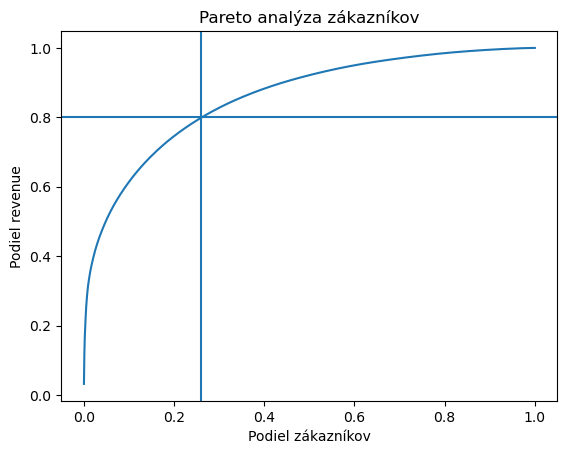

In [69]:
#pridanie 80 % a 26 % čiar
plt.figure()

plt.plot(
    customer_profile_sorted['customer_pct'],
    customer_profile_sorted['cum_revenue_pct']
)

plt.axhline(y=0.8)
plt.axvline(x=0.26)

plt.xlabel('Podiel zákazníkov')
plt.ylabel('Podiel revenue')
plt.title('Pareto analýza zákazníkov')

plt.show()

In [70]:
#revenue podľa segmentov
#spočítame revenue podľa segmentov
segment_revenue = customer_profile.groupby('segment').agg(
    total_revenue=('total_revenue', 'sum'),
    customer_count=('CustomerID', 'count')
).reset_index()

segment_revenue

,segment,total_revenue,customer_count
0,Active,1504425.640,1391
1,At Risk,740193.732,839
2,Churn,557828.741,867
3,Loyal,1681022.721,626
4,VIP,4296353.180,613


In [71]:
#pridáme percentá
total_revenue_all = segment_revenue['total_revenue'].sum()

segment_revenue['revenue_pct'] = (
    segment_revenue['total_revenue'] / total_revenue_all
)

segment_revenue

,segment,total_revenue,customer_count,revenue_pct
0,Active,1504425.640,1391,0.171350
1,At Risk,740193.732,839,0.084306
2,Churn,557828.741,867,0.063535
3,Loyal,1681022.721,626,0.191464
4,VIP,4296353.180,613,0.489344


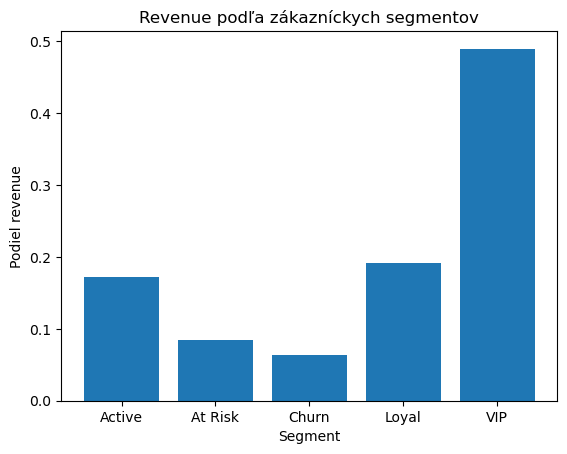

In [72]:
#vizualizácia-bar chart
import matplotlib.pyplot as plt

plt.figure()

plt.bar(
    segment_revenue['segment'],
    segment_revenue['revenue_pct']
)

plt.xlabel('Segment')
plt.ylabel('Podiel revenue')
plt.title('Revenue podľa zákazníckych segmentov')

plt.show()

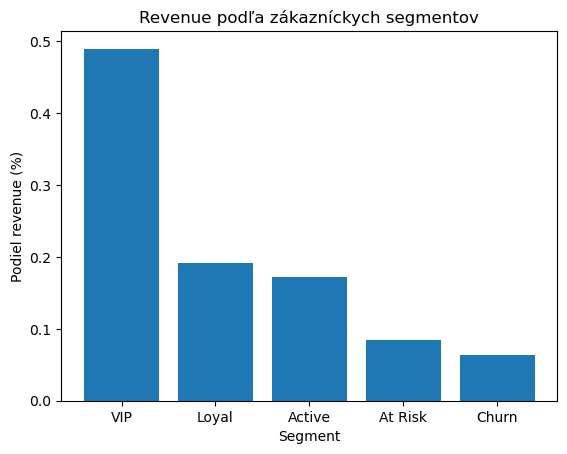

In [73]:
#upgrade grafu-zoradenie + percentá na osi
segment_revenue_sorted = segment_revenue.sort_values(
    by='revenue_pct', ascending=False
)

plt.figure()

plt.bar(
    segment_revenue_sorted['segment'],
    segment_revenue_sorted['revenue_pct']
)

plt.xlabel('Segment')
plt.ylabel('Podiel revenue (%)')
plt.title('Revenue podľa zákazníckych segmentov')

plt.show()

In [74]:
#začíname CHURN analýzu
#najprv sa pozrieme, ako sú zákazníci rozdelení do cenových pásiem
customer_profile['recency_bucket'] = pd.cut(
    customer_profile['recency_days'],
    bins=[0, 30, 90, 180, 365, 1000],
    labels=['0-30', '31-90', '91-180', '181-365', '365+']
)

customer_profile['recency_bucket'].value_counts().sort_index()

recency_bucket
0-30       1648
31-90      1239
91-180      587
181-365     793
365+         69
Name: count, dtype: int64

In [75]:
#vytvorenie churn flagu-za churn sme si definovali 90 dní
customer_profile['churn'] = (
    customer_profile['recency_days'] >= 90
).astype(int)

customer_profile[['CustomerID', 'recency_days', 'churn']].head()

,CustomerID,recency_days,churn
0,12346,326,1
1,12347,2,0
2,12348,75,0
3,12349,19,0
4,12350,310,1


In [76]:
#spočítame koľko máme churn zákazníkov
customer_profile['churn'].value_counts(normalize=True)

churn
0    0.663745
1    0.336255
Name: proportion, dtype: float64

In [77]:
#spojíme churn a segment-chceme vedieť, ktorý segment odchádza najviav
pd.crosstab(
    customer_profile['segment'],
    customer_profile['churn'],
    normalize='index'
)

churn,0,1
segment,,
Active,1.00000,0.00000
At Risk,0.29559,0.70441
Churn,0.00000,1.00000
Loyal,1.00000,0.00000
VIP,1.00000,0.00000


In [78]:
# predikcia-Feature engineering a ML
#vytvoríme základné features pre model
ml_df = customer_profile[['recency_days', 'num_orders', 'total_revenue', 'churn']]

ml_df.head()

,recency_days,num_orders,total_revenue,churn
0,326,1,77183.60,1
1,2,7,4310.00,0
2,75,4,1437.24,0
3,19,1,1457.55,0
4,310,1,294.40,1


In [79]:
#train/test dáta
from sklearn.model_selection import train_test_split

X = ml_df[['recency_days', 'num_orders', 'total_revenue']]
y = ml_df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((3468, 3), (868, 3))

In [80]:
#LOGIT model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [81]:
#predikcia modelu
y_pred = model.predict(X_test)

y_pred[:10]

array([1, 0, 1, 0, 0, 0, 1, 1, 0, 0])

In [82]:
#vyhodnotenie modelu
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

accuracy

1.0

In [83]:
#upravíme dataset, lebo vstupná recency-days priamo predpovedá churn. Nie je to dobrý vstup
ml_df_2 = customer_profile[['num_orders', 'total_revenue', 'churn']]

ml_df_2.head()

,num_orders,total_revenue,churn
0,1,77183.60,1
1,7,4310.00,0
2,4,1437.24,0
3,1,1457.55,0
4,1,294.40,1


In [84]:
from sklearn.model_selection import train_test_split

X = ml_df_2[['num_orders', 'total_revenue']]
y = ml_df_2['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((3468, 2), (868, 2))

In [85]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [86]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 1])

In [87]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.695852534562212

In [88]:
#urobíme Confusion matrix, aby sme videli, kde robí model chyby
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[429, 132],
       [132, 175]])

In [89]:
#metriky Precision a Recall
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

precision, recall

(0.5700325732899023, 0.5700325732899023)

In [90]:
#GPT navrhuje vytvoriť ďalšie features lebo teraz sme pracovali len s 2 vyvsetľujúcimi premennými
customer_profile['avg_order_value'] = (
    customer_profile['total_revenue'] / customer_profile['num_orders']
)

customer_profile[['total_revenue', 'num_orders', 'avg_order_value']].head()

,total_revenue,num_orders,avg_order_value
0,77183.60,1,77183.600000
1,4310.00,7,615.714286
2,1437.24,4,359.310000
3,1457.55,1,1457.550000
4,294.40,1,294.400000


In [91]:
#nový dataset
ml_df_3 = customer_profile[
    ['num_orders', 'total_revenue', 'avg_order_value', 'churn']
]

ml_df_3.head()

,num_orders,total_revenue,avg_order_value,churn
0,1,77183.60,77183.600000,1
1,7,4310.00,615.714286,0
2,4,1437.24,359.310000,0
3,1,1457.55,1457.550000,0
4,1,294.40,294.400000,1


In [92]:
#train/test split
from sklearn.model_selection import train_test_split

X = ml_df_3[['num_orders', 'total_revenue', 'avg_order_value']]
y = ml_df_3['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((3468, 3), (868, 3))

In [93]:
#nový model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [94]:
#predikcie + accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.695852534562212

In [95]:
#skúsime iný mnodel-Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [96]:
y_pred_rf = model_rf.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

accuracy_rf

0.6324884792626728

In [97]:
#ďalší upgrade modelu-p(x) churnu-dotera som mal len 1/0 (odíde/neodíde), teraz chcem p(x) odchodu (churn)
y_proba = model.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.41244687, 0.14997842, 0.4118119 , 0.21615177, 0.41228039,
       0.52764587, 0.526557  , 0.41230219, 0.30553567, 0.52669843])

In [98]:
#spravíme risk segmenty
import numpy as np

risk_segment = np.where(
    y_proba < 0.3, 'Low Risk',
    np.where(y_proba < 0.6, 'Medium Risk', 'High Risk')
)

risk_segment[:10]

array(['Medium Risk', 'Low Risk', 'Medium Risk', 'Low Risk',
       'Medium Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk',
       'Medium Risk', 'Medium Risk'], dtype='<U11')

In [99]:
#koľko je zákazníkov v každom risk segmente?
import pandas as pd

pd.Series(risk_segment).value_counts()


Medium Risk    563
Low Risk       305
Name: count, dtype: int64